<a href="https://colab.research.google.com/github/RAJDONDA89/Group-project_-Advance-Forecasting/blob/notebooks/SARIMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#Python interactiveshell
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# **1. Introduction**

This is my individual notebook for group project focusing on predicting the monthly car sales using SARIMA model. As discussed within the group, data preparation, data cleaning, and EDA was done in the group notebook and also how to define and evaluate the models individually. I have used one main forecasting model and one basic baseline method. The baseline method is for  comparision and I chose SARIMA model because the data clearly shows trends and repeated annual patterns.

The aim is to predict 12 month sales forecast, to achieve this i have taken the past 12 months data as a test set and used MAE and RMSE to test the model performance.

GitHub Repository link: https://github.com/RAJDONDA89/Group-project_-Advance-Forecasting.git

# **2.Importing Libraries**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

import warnings
warnings.filterwarnings("ignore")

# **3. Data loading**

In [4]:
url = "https://raw.githubusercontent.com/RAJDONDA89/Group-project_-Advance-Forecasting/refs/heads/main/Data/monthly-car-sales.csv"

df = pd.read_csv(url)
df.columns = ["Date", "Sales"]
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)
df.head()

,Sales
Date,
1960-01-01,6550
1960-02-01,8728
1960-03-01,12026
1960-04-01,14395
1960-05-01,14587


The dataset was imported from the group github repository, the date column is converted into datetime format and set as index for timeseries forecasting.

In [5]:
df.info()
print("\n")

df.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 108 entries, 1960-01-01 to 1968-12-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Sales   108 non-null    int64
dtypes: int64(1)
memory usage: 1.7 KB




,Sales
count,108.000000
mean,14595.111111
std,4525.213913
min,5568.000000
25%,11391.250000
50%,14076.000000
75%,17595.750000
max,26099.000000


<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'Monthly Car Sales')

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Sales')

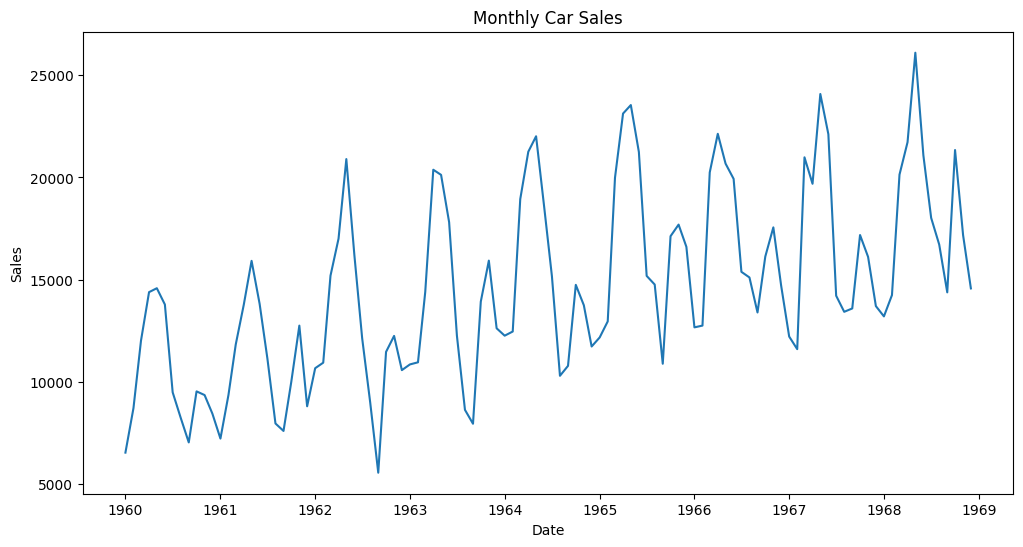

In [6]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df["Sales"])

plt.title("Monthly Car Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

The graph shows that car sale never remained the same throughout the years and there were consistent ups and downs in the values. At the same time, sales generally increased over time, which suggests an upward trend. This pattern also seems to be repeating every year, proving that the dataset may contain seasonality. This data which has trends makes the data to be in a time series forecasting.

# **4. Train-Test Split**

In [7]:
train = df[:-12]
test = df[-12:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 96
Testing observations: 12


Here i have divided the data into two, first 96 observations are used for training the model and the latest 12 observations are for testing, this helps the data to evaluate the unseen 12 observations for prediction.

<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'Train-Test Split')

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Sales')

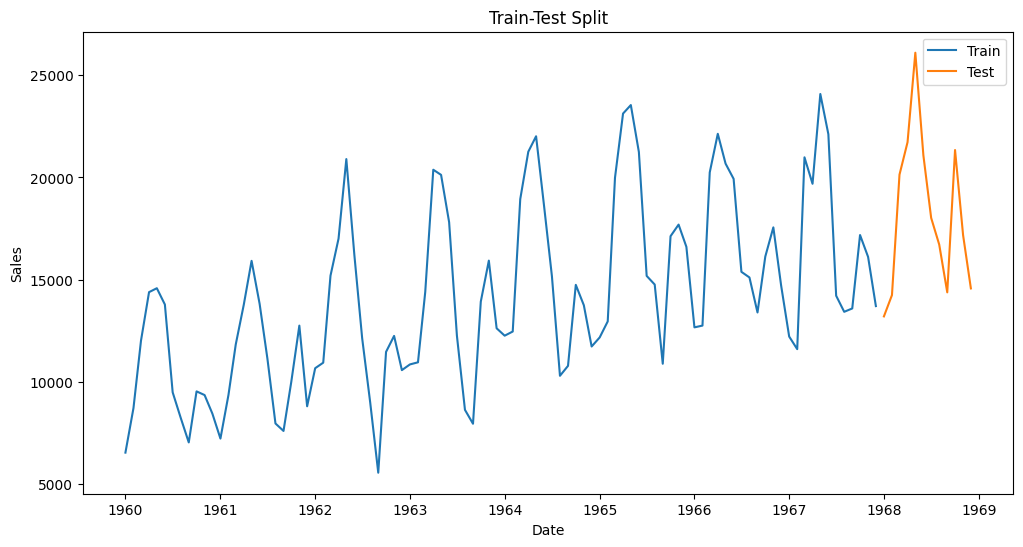

In [8]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train["Sales"], label="Train")
plt.plot(test.index, test["Sales"], label="Test")

plt.title("Train-Test Split")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.show()

Here i have created a graph to show the train and test data. Blue line shows the training data and orange line shows the test data.

# **5. Baseline Model**

In [9]:
baseline_forecast = train["Sales"].iloc[-12:].values

baseline_results = pd.DataFrame({
    "Actual": test["Sales"].values,
    "Baseline_Forecast": baseline_forecast
}, index=test.index)

baseline_results

baseline_mae = mean_absolute_error(test["Sales"], baseline_forecast)
baseline_rmse = np.sqrt(mean_squared_error(test["Sales"], baseline_forecast))

print("Baseline MAE:", round(baseline_mae, 2))
print("Baseline RMSE:", round(baseline_rmse, 2))

,Actual,Baseline_Forecast
Date,,
1968-01-01,13210,12225
1968-02-01,14251,11608
1968-03-01,20139,20985
1968-04-01,21725,19692
1968-05-01,26099,24081
1968-06-01,21084,22114
1968-07-01,18024,14220
1968-08-01,16722,13434
1968-09-01,14385,13598


Baseline MAE: 1959.5
Baseline RMSE: 2290.83


For baseline model I have used seasonal naive method to predict the future sales using values from same month in the previous year. The MAE and RMSE results will be used later to compare the performance of SARIMA model.

<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'Baseline Forecast vs Actual Sales')

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Sales')

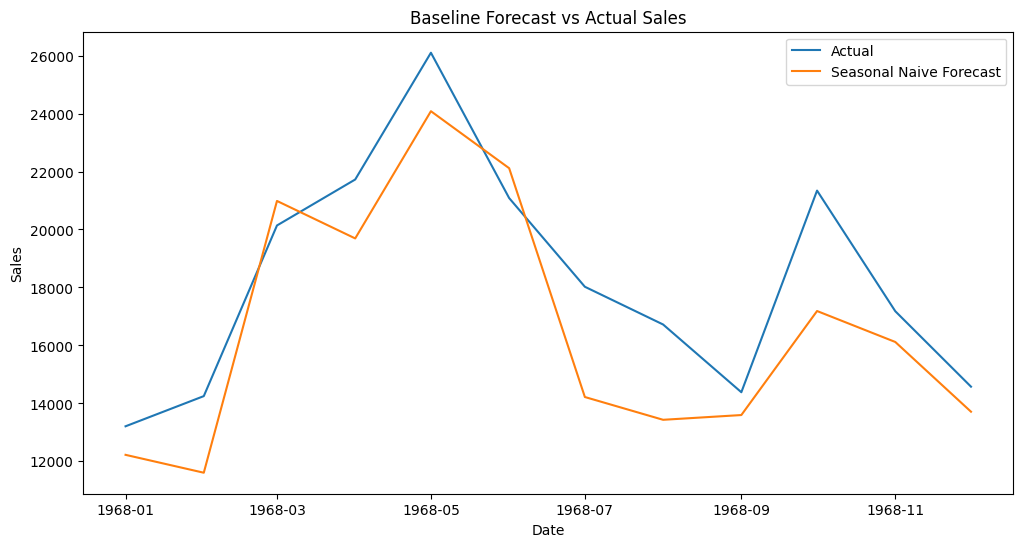

In [10]:
plt.figure(figsize=(12,6))

plt.plot(test.index, test["Sales"], label="Actual")
plt.plot(test.index, baseline_forecast, label="Seasonal Naive Forecast")

plt.title("Baseline Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.show()

The graph compares the actual sales values with the forcasting values of the seasonal naive baseline model. It can be seen that there is obvious difference between the actual sales and predicted values in some months, it captures seasonal patterns and errors are still present in the predicted values.

# **6. Tuning & Stationarity test**


## **6.1 ADF**

In [22]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(train["Sales"])

print("ADF Statistic:", round(result[0], 4))
print("p-value:", round(result[1], 4))
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {round(value, 4)}")

ADF Statistic: -1.6886
p-value: 0.437
Critical Values:
   1%: -3.5117
   5%: -2.897
   10%: -2.5857


## **6.2 Hyperparameter Tuning**

In [17]:
!pip install pmdarima
from pmdarima import auto_arima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 3.2 MB/s eta 0:00:00


In [18]:
auto_model = auto_arima(
    train["Sales"],
    seasonal=True,
    m=12,
    d=1, D=1,
    start_p=0, max_p=2,
    start_q=0, max_q=2,
    start_P=0, max_P=1,
    start_Q=0, max_Q=1,
    information_criterion="aic",
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True
)

print("Best order:", auto_model.order)
print("Best seasonal order:", auto_model.seasonal_order)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1509.830, Time=0.06 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1477.230, Time=0.80 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1470.387, Time=0.69 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=1483.707, Time=0.14 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=1469.761, Time=0.57 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=1467.787, Time=0.35 sec
 ARIMA(0,1,0)(1,1,0)[12]             : AIC=1493.201, Time=0.12 sec
 ARIMA(1,1,1)(1,1,0)[12]             : AIC=1467.572, Time=0.56 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=1485.804, Time=0.11 sec
 ARIMA(1,1,1)(1,1,1)[12]             : AIC=1469.354, Time=0.86 sec
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=1469.716, Time=1.02 sec
 ARIMA(2,1,1)(1,1,0)[12]             : AIC=1468.848, Time=2.20 sec
 ARIMA(1,1,2)(1,1,0)[12]             : AIC=inf, Time=1.70 sec
 ARIMA(0,1,2)(1,1,0)[12]             : AIC=1468.200, Time=0.45 sec
 ARIMA(2,1,0)(1,1,0)[12]

# **7. SARIMA Model**

In [20]:
model = SARIMAX(
    train["Sales"],
    order=auto_model.order,
    seasonal_order=auto_model.seasonal_order
)

sarima_model = model.fit()

print(sarima_model.summary())

forecast_result = sarima_model.get_forecast(steps=12)
sarima_forecast = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

sarima_forecast

                                      SARIMAX Results                                      
Dep. Variable:                               Sales   No. Observations:                   96
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 12)   Log Likelihood                -729.786
Date:                             Thu, 07 May 2026   AIC                           1467.572
Time:                                     11:58:36   BIC                           1477.248
Sample:                                 01-01-1960   HQIC                          1471.459
                                      - 12-01-1967                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2169      0.140      1.545      0.122      -0.058       0.492
ma.L1         -0.8626      

,predicted_mean
1968-01-01,11804.106191
1968-02-01,11762.942073
1968-03-01,20363.384725
1968-04-01,20487.285425
1968-05-01,22295.891741
1968-06-01,20869.777867
1968-07-01,14455.432989
1968-08-01,13895.211180
1968-09-01,13230.434158
1968-10-01,16441.711857


Reflectioin:

<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'SARIMA Forecast vs Actual Sales')

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Sales')

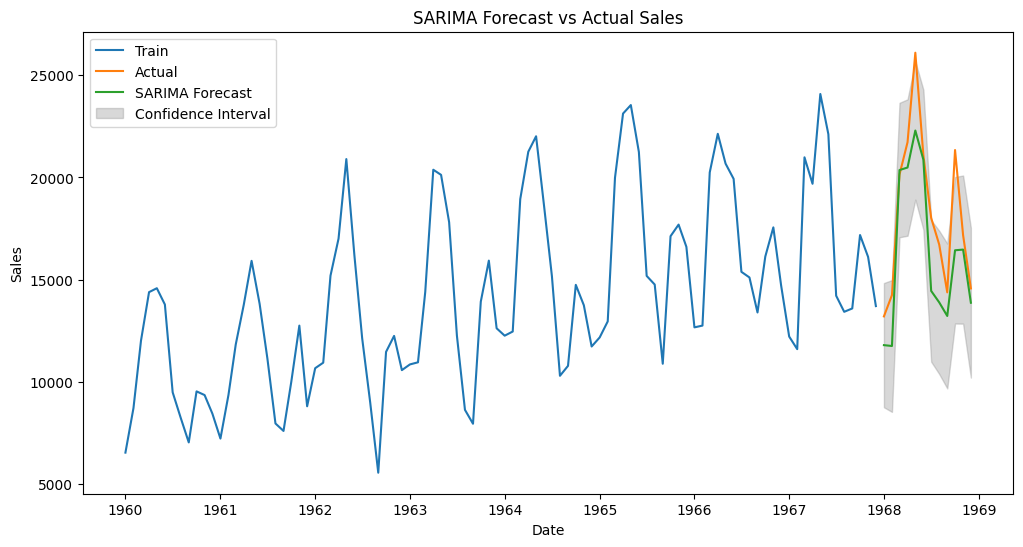

In [23]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train["Sales"], label="Train")
plt.plot(test.index, test["Sales"], label="Actual")
plt.plot(test.index, sarima_forecast, label="SARIMA Forecast")

plt.fill_between(
    test.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color='gray',
    alpha=0.3,
    label="Confidence Interval"
)

plt.title("SARIMA Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.show()

The graph compares the training data, actual test values and the SARIMA forecast. The green line is almost moving the same as the blue line following the trends, but there are still some gaps can be seen between the predicted and actual values.

# **8. Model Evaluation**

In [13]:
sarima_mae = mean_absolute_error(test["Sales"], sarima_forecast)

sarima_rmse = np.sqrt(
    mean_squared_error(test["Sales"], sarima_forecast)
)

print("SARIMA MAE:", round(sarima_mae, 2))
print("SARIMA RMSE:", round(sarima_rmse, 2))

SARIMA MAE: 1819.49
SARIMA RMSE: 2333.74


The above MAE and RMSE results shows that the model captured the flow and pattern in te main data with slight forcasting error.

In [14]:
comparison = pd.DataFrame({
    "Model": ["Seasonal Naive", "SARIMA"],
    "MAE": [baseline_mae, sarima_mae],
    "RMSE": [baseline_rmse, sarima_rmse]
})

comparison

,Model,MAE,RMSE
0,Seasonal Naive,1959.500000,2290.827252
1,SARIMA,1819.487451,2333.737023


The above comparision shows that the SARIMA model achieved lower MAE than the Seasonal Naive baseline model which is slightly better overall forcasting accuracy but the SARIMA RMSE is slightly higher which means that some larger forcasting errors are still present.

# **8. Residual Analysis**

<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'SARIMA Residuals')

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Residuals')

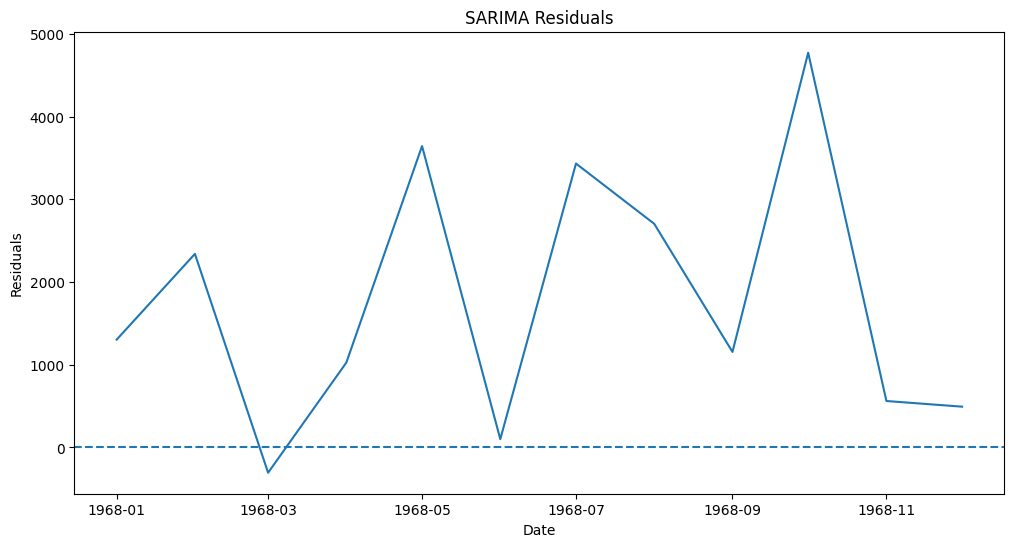

In [15]:
residuals = test["Sales"] - sarima_forecast

plt.figure(figsize=(12,6))

plt.plot(test.index, residuals)

plt.axhline(0, linestyle="--")

plt.title("SARIMA Residuals")
plt.xlabel("Date")
plt.ylabel("Residuals")

plt.show()

The above residual plot shows the forcasting errors made by the SARIMA model for each month. Most of the values stay close to zero but whereas at some point there are larger errors in some months. Overall, the model captures patterns and trends in the data reasonably well.  

## **8.1 Distribution of Residuals**

<Figure size 800x500 with 0 Axes>

(array([2., 2., 3., 0., 2., 1., 1., 1.]),
 array([-306.11347338,  328.67224265,  963.45795869, 1598.24367472,
        2233.02939075, 2867.81510678, 3502.60082281, 4137.38653884,
        4772.17225488]),
 <BarContainer object of 8 artists>)

Text(0.5, 1.0, 'Distribution of Residuals')

Text(0.5, 0, 'Residual')

Text(0, 0.5, 'Frequency')

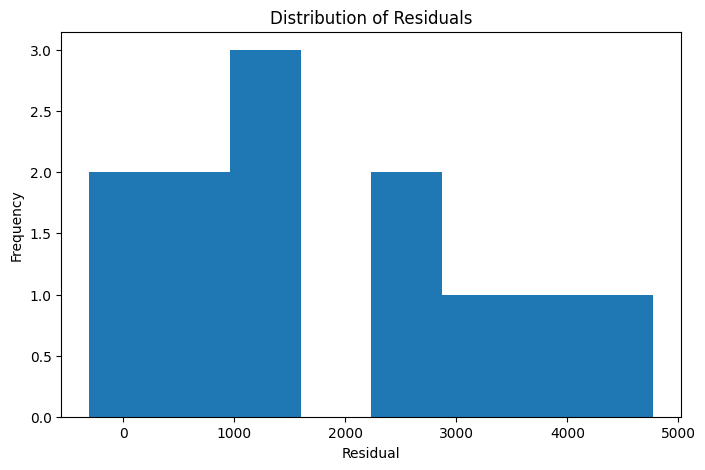

In [16]:
plt.figure(figsize=(8,5))

plt.hist(residuals, bins=8)

plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

The above histogram shows the distribution of the residual values of the SARIMA model. The majority of errors are in a moderate range, but there are also a few larger errors in forecasting.

# **9. Discussion and reflection**

The SARIMA model recorded the main seasonal cycle and overall trend in the data reasonably well. When compared to the seasonal naïve baseline, which was based on the MAE metric, the results were slightly better, but there were still some larger forecasting errors. All in all, SARIMA was suitable in this dataset since the data had both trend and yearly seasonality.

# **10. Conclusion**

In this project, the SARIMA model was used to predict monthly car sales. The model was able to capture the overall trend and seasonal behaviour in the series and performed slightly better than the baseline model. The findings indicate that SARIMA could be useful in predicting seasonal time series data.